# 공기저항 유무에 따른 포물선 운동과 역학적 에너지

이상적인 구체에 작용하는 공기저항을 $\vec{F}_d=-\frac{1}{2}\rho C_d A|\vec{v}|\vec{v}$로 두고 RK4 방법으로 운동을 계산합니다. 구체의 회전, 마그누스 효과와 바람은 무시합니다.

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# 초기 조건과 물리량 (원하는 값으로 변경)
launch_angle = 45.0          # 초기 발사각 (degree)
initial_speed = 40.0         # 초기 속력 (m/s), 약 144 km/h
mass = 0.145                 # 규격 야구공 질량 (kg)
radius = 0.0366              # 규격 야구공 반지름 (m)
drag_coefficient = 0.47      # 회전하지 않는 야구공의 근사 항력계수
air_density = 3          # 해수면 공기 밀도 (kg/m^3)
gravity = 9.81               # 중력가속도 (m/s^2)
dt = 0.05                  # 계산 시간 간격 (s)

cross_sectional_area = np.pi * radius**2
air_resistance = 0.5 * air_density * drag_coefficient * cross_sectional_area

print(f'구체 단면적: {cross_sectional_area:.6f} m^2')
print(f'공기저항 상수 (1/2 rho Cd A): {air_resistance:.6f} kg/m')

구체 단면적: 0.004208 m^2
공기저항 상수 (1/2 rho Cd A): 0.002967 kg/m


In [77]:
def acceleration(vx, vy, with_drag):
    if not with_drag:
        return np.array([0.0, -gravity])

    speed = np.hypot(vx, vy)
    drag_acceleration = -(air_resistance / mass) * speed * np.array([vx, vy])
    return drag_acceleration + np.array([0.0, -gravity])


def derivative(state, with_drag):
    x, y, vx, vy = state
    ax, ay = acceleration(vx, vy, with_drag)
    return np.array([vx, vy, ax, ay])


def rk4_step(state, step, with_drag):
    k1 = derivative(state, with_drag)
    k2 = derivative(state + step * k1 / 2, with_drag)
    k3 = derivative(state + step * k2 / 2, with_drag)
    k4 = derivative(state + step * k3, with_drag)
    return state + step * (k1 + 2*k2 + 2*k3 + k4) / 6


def simulate(with_drag, angle_degrees=launch_angle, max_time=120.0):
    angle = np.radians(angle_degrees)
    state = np.array([
        0.0, 0.0,
        initial_speed * np.cos(angle),
        initial_speed * np.sin(angle),
    ])
    times = [0.0]
    states = [state.copy()]

    while times[-1] < max_time:
        next_state = rk4_step(state, dt, with_drag)
        next_time = times[-1] + dt

        if next_state[1] < 0.0:
            # 마지막 두 점 사이를 선형 보간해 정확히 지면(y=0)에서 끝낸다.
            fraction = state[1] / (state[1] - next_state[1])
            ground_state = state + fraction * (next_state - state)
            ground_state[1] = 0.0
            times.append(times[-1] + fraction * dt)
            states.append(ground_state)
            break

        times.append(next_time)
        states.append(next_state.copy())
        state = next_state
    else:
        raise RuntimeError('max_time 안에 구체가 지면에 도달하지 않았습니다.')

    return np.array(times), np.array(states)


def calculate_energy(states):
    y = states[:, 1]
    vx, vy = states[:, 2], states[:, 3]
    kinetic = 0.5 * mass * (vx**2 + vy**2)
    potential = mass * gravity * y
    return kinetic, potential, kinetic + potential


time_no_drag, state_no_drag = simulate(with_drag=False)
time_drag, state_drag = simulate(with_drag=True)
ke_no_drag, pe_no_drag, total_no_drag = calculate_energy(state_no_drag)
ke_drag, pe_drag, total_drag = calculate_energy(state_drag)

print(f'공기저항 없음: 비행시간 {time_no_drag[-1]:.3f} s, 수평거리 {state_no_drag[-1, 0]:.3f} m')
print(f'공기저항 있음: 비행시간 {time_drag[-1]:.3f} s, 수평거리 {state_drag[-1, 0]:.3f} m')

공기저항 없음: 비행시간 5.766 s, 수평거리 163.096 m
공기저항 있음: 비행시간 3.986 s, 수평거리 53.530 m


## 1-2. 공기저항 유무에 따른 거리-높이 그래프

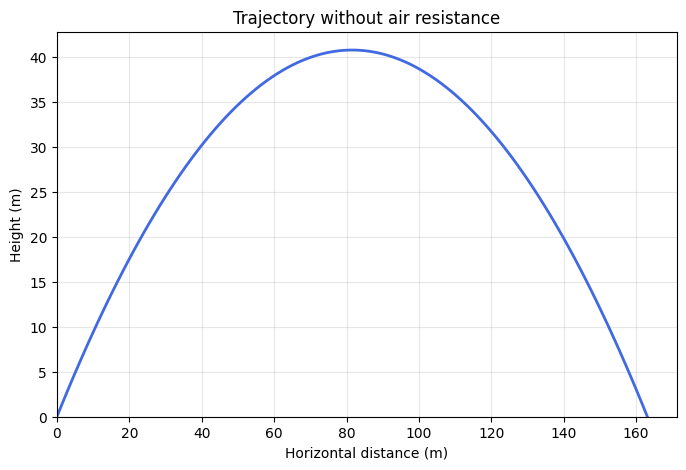

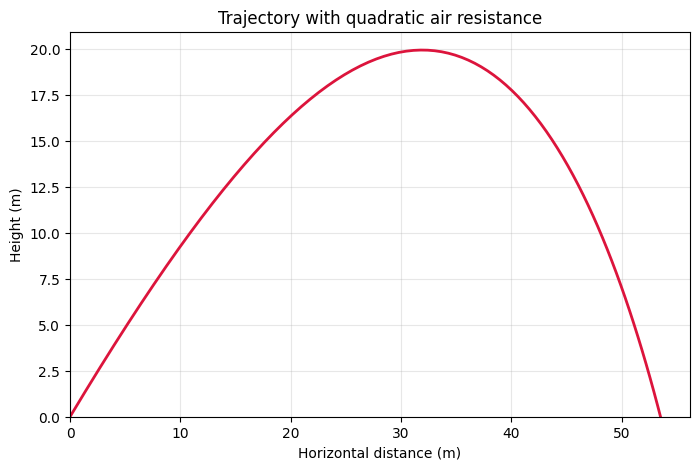

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(state_no_drag[:, 0], state_no_drag[:, 1], color='royalblue', linewidth=2)
plt.xlabel('Horizontal distance (m)')
plt.ylabel('Height (m)')
plt.title('Trajectory without air resistance')
plt.grid(alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(state_drag[:, 0], state_drag[:, 1], color='crimson', linewidth=2)
plt.xlabel('Horizontal distance (m)')
plt.ylabel('Height (m)')
plt.title('Trajectory with quadratic air resistance')
plt.grid(alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

<!-- 2번 그래프는 위의 1-2 통합 코드 셀에 포함되어 있습니다. -->

## 3-4. 공기저항 유무에 따른 시간-에너지 그래프

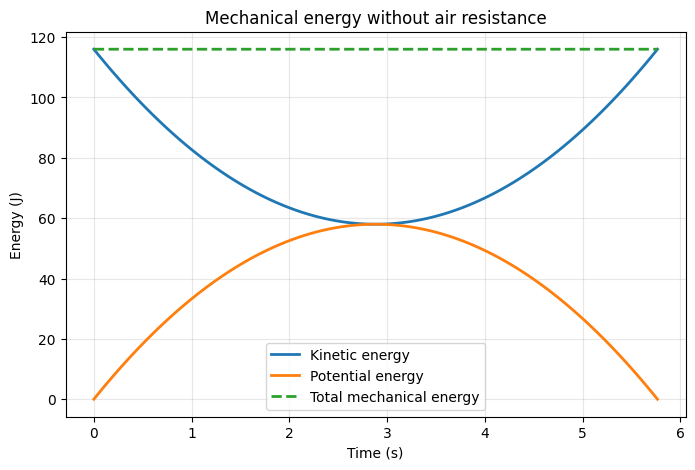

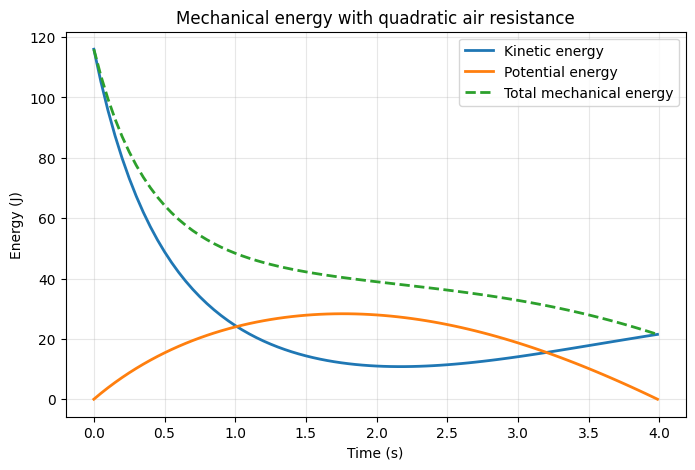

In [79]:
plt.figure(figsize=(8, 5))
plt.plot(time_no_drag, ke_no_drag, label='Kinetic energy', linewidth=2)
plt.plot(time_no_drag, pe_no_drag, label='Potential energy', linewidth=2)
plt.plot(time_no_drag, total_no_drag, label='Total mechanical energy', linewidth=2, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Mechanical energy without air resistance')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(time_drag, ke_drag, label='Kinetic energy', linewidth=2)
plt.plot(time_drag, pe_drag, label='Potential energy', linewidth=2)
plt.plot(time_drag, total_drag, label='Total mechanical energy', linewidth=2, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Mechanical energy with quadratic air resistance')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<!-- 4번 그래프는 위의 3-4 통합 코드 셀에 포함되어 있습니다. -->

## 5. 발사각에 따른 수평 도달거리, 최대 높이와 비행시간

같은 초기 속력으로 발사각만 바꾸어 공기저항 유무에 따른 도달거리, 최대 높이와 비행시간을 비교합니다.

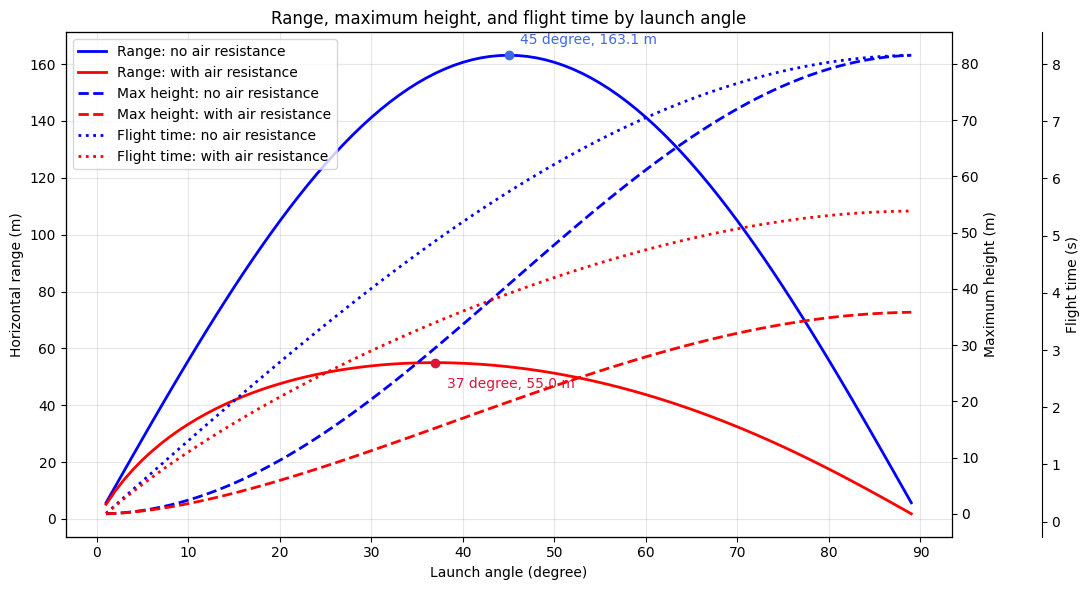

공기저항 없음 최대 거리: 45도, 163.10 m
공기저항 있음 최대 거리: 37도, 54.98 m


In [80]:
angles = np.arange(1.0, 90.0, 1.0)

# 공기저항이 없을 때는 동일 높이에서 발사하고 착지하는 해석해를 사용한다.
ranges_no_drag = initial_speed**2 * np.sin(2 * np.radians(angles)) / gravity
max_heights_no_drag = (initial_speed * np.sin(np.radians(angles)))**2 / (2 * gravity)
flight_times_no_drag = 2 * initial_speed * np.sin(np.radians(angles)) / gravity
drag_results = [simulate(with_drag=True, angle_degrees=a) for a in angles]
drag_states = [result[1] for result in drag_results]
ranges_drag = np.array([states[-1, 0] for states in drag_states])
max_heights_drag = np.array([np.max(states[:, 1]) for states in drag_states])
flight_times_drag = np.array([result[0][-1] for result in drag_results])

best_no_drag = np.argmax(ranges_no_drag)
best_drag = np.argmax(ranges_drag)

fig, ax_range = plt.subplots(figsize=(11, 6))
ax_height = ax_range.twinx()
ax_time = ax_range.twinx()
ax_time.spines['right'].set_position(('outward', 65))

range_no_drag_line, = ax_range.plot(angles, ranges_no_drag, label='Range: no air resistance', color='blue', linewidth=2, linestyle='-')
range_drag_line, = ax_range.plot(angles, ranges_drag, label='Range: with air resistance', color='red', linewidth=2, linestyle='-')
height_no_drag_line, = ax_height.plot(angles, max_heights_no_drag, label='Max height: no air resistance', color='blue', linewidth=2, linestyle='--')
height_drag_line, = ax_height.plot(angles, max_heights_drag, label='Max height: with air resistance', color='red', linewidth=2, linestyle='--')
time_no_drag_line, = ax_time.plot(angles, flight_times_no_drag, label='Flight time: no air resistance', color='blue', linewidth=2, linestyle=':')
time_drag_line, = ax_time.plot(angles, flight_times_drag, label='Flight time: with air resistance', color='red', linewidth=2, linestyle=':')

ax_range.scatter(angles[best_no_drag], ranges_no_drag[best_no_drag], color='royalblue', zorder=3)
ax_range.scatter(angles[best_drag], ranges_drag[best_drag], color='crimson', zorder=3)
ax_range.annotate(f'{angles[best_no_drag]:.0f} degree, {ranges_no_drag[best_no_drag]:.1f} m',
             (angles[best_no_drag], ranges_no_drag[best_no_drag]), xytext=(8, 8),
             textcoords='offset points', color='royalblue')
ax_range.annotate(f'{angles[best_drag]:.0f} degree, {ranges_drag[best_drag]:.1f} m',
             (angles[best_drag], ranges_drag[best_drag]), xytext=(8, -18),
             textcoords='offset points', color='crimson')
ax_range.set_xlabel('Launch angle (degree)')
ax_range.set_ylabel('Horizontal range (m)')
ax_height.set_ylabel('Maximum height (m)')
ax_time.set_ylabel('Flight time (s)')
ax_range.set_title('Range, maximum height, and flight time by launch angle')
ax_range.set_xticks(np.arange(0, 91, 10))
ax_range.grid(alpha=0.3)
lines = [range_no_drag_line, range_drag_line, height_no_drag_line, height_drag_line, time_no_drag_line, time_drag_line]
ax_range.legend(lines, [line.get_label() for line in lines], loc='upper left')
fig.tight_layout()
plt.show()

print(f'공기저항 없음 최대 거리: {angles[best_no_drag]:.0f}도, {ranges_no_drag[best_no_drag]:.2f} m')
print(f'공기저항 있음 최대 거리: {angles[best_drag]:.0f}도, {ranges_drag[best_drag]:.2f} m')

## 6. 시간에 따른 수평·수직속도

공기저항 유무에 따른 수평속도와 수직속도의 변화를 비교합니다.

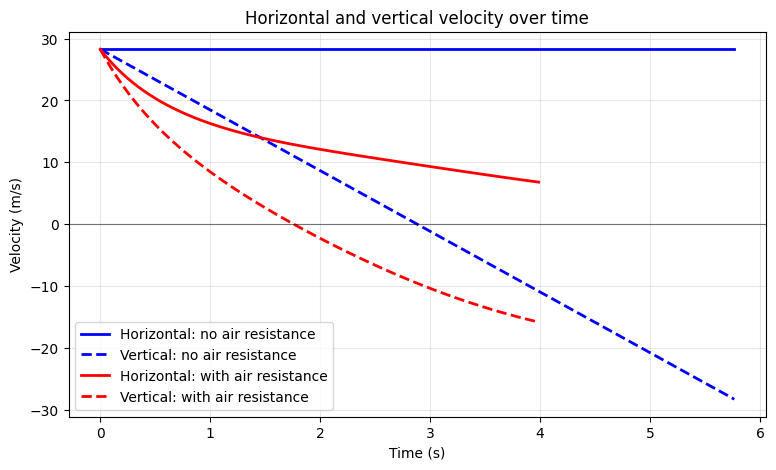

In [81]:
plt.figure(figsize=(9, 5))
plt.plot(time_no_drag, state_no_drag[:, 2], color='blue', linestyle='-', linewidth=2, label='Horizontal: no air resistance')
plt.plot(time_no_drag, state_no_drag[:, 3], color='blue', linestyle='--', linewidth=2, label='Vertical: no air resistance')
plt.plot(time_drag, state_drag[:, 2], color='red', linestyle='-', linewidth=2, label='Horizontal: with air resistance')
plt.plot(time_drag, state_drag[:, 3], color='red', linestyle='--', linewidth=2, label='Vertical: with air resistance')
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Horizontal and vertical velocity over time')
plt.grid(alpha=0.3)
plt.legend()
plt.show()